<a href="https://colab.research.google.com/github/Aarthielango985/Data-Analytics-task1-EDA-Analysis-/blob/main/EDA_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
#importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [19]:
# CSV File Data Loading
df = pd.read_csv("/retail_sales_dataset.csv")

# OR Excel File
# df = pd.read_excel("Retail_Sales.xlsx")

In [20]:
print(df.head())

   Transaction ID        Date Customer ID  Gender  Age Product Category  \
0               1  2023-11-24     CUST001    Male   34           Beauty   
1               2  2023-02-27     CUST002  Female   26         Clothing   
2               3  2023-01-13     CUST003    Male   50      Electronics   
3               4  2023-05-21     CUST004    Male   37         Clothing   
4               5  2023-05-06     CUST005    Male   30           Beauty   

   Quantity  Price per Unit  Total Amount  
0         3              50           150  
1         2             500          1000  
2         1              30            30  
3         1             500           500  
4         2              50           100  


In [22]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB
None


In [23]:
print("Rows:",df.shape[0])
print("Columns:",df.shape[1])

Rows: 1000
Columns: 9


In [24]:
#Data Cleaning
print(df.isnull().sum())

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64


In [25]:
df.drop_duplicates(inplace=True)

In [26]:
# Fill missing values in numerical columns
for col in df.select_dtypes(include='number').columns:
    df[col] = df[col].fillna(df[col].median())

# Fill missing values in categorical columns
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].fillna(df[col].mode()[0])

# Check if any missing values remain
print(df.isnull().sum())

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64


In [27]:
print(df.dtypes)

Transaction ID       int64
Date                object
Customer ID         object
Gender              object
Age                  int64
Product Category    object
Quantity             int64
Price per Unit       int64
Total Amount         int64
dtype: object


In [28]:
#DISCRIPTIVE STATERSTICS
print(df.describe())

       Transaction ID         Age     Quantity  Price per Unit  Total Amount
count     1000.000000  1000.00000  1000.000000     1000.000000   1000.000000
mean       500.500000    41.39200     2.514000      179.890000    456.000000
std        288.819436    13.68143     1.132734      189.681356    559.997632
min          1.000000    18.00000     1.000000       25.000000     25.000000
25%        250.750000    29.00000     1.000000       30.000000     60.000000
50%        500.500000    42.00000     3.000000       50.000000    135.000000
75%        750.250000    53.00000     4.000000      300.000000    900.000000
max       1000.000000    64.00000     4.000000      500.000000   2000.000000


In [29]:
#Mean
print(df.mean(numeric_only=True))

Transaction ID    500.500
Age                41.392
Quantity            2.514
Price per Unit    179.890
Total Amount      456.000
dtype: float64


In [ ]:
#Median
print(df.median(numeric_only=True))

Transaction ID    500.5
Age                42.0
Quantity            3.0
Price per Unit     50.0
Total Amount      135.0
dtype: float64


In [30]:
#Mode
print(df.mode().iloc[0])

Transaction ID               1
Date                2023-05-16
Customer ID            CUST001
Gender                  Female
Age                       43.0
Product Category      Clothing
Quantity                   4.0
Price per Unit            50.0
Total Amount              50.0
Name: 0, dtype: object


In [31]:
#Standard deviation
print(df.std(numeric_only=True))

Transaction ID    288.819436
Age                13.681430
Quantity            1.132734
Price per Unit    189.681356
Total Amount      559.997632
dtype: float64


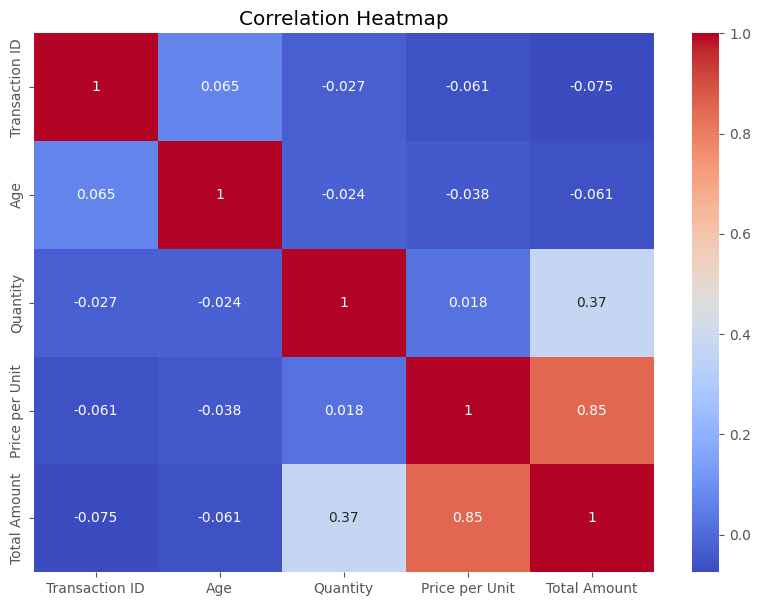

In [33]:
#CORRELATION ANALYSIS
correlation = df.corr(numeric_only=True)

plt.figure(figsize=(10,7))
sns.heatmap(correlation,
            annot=True,
            cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [34]:
#TIME SERIES ANALYSIS
print(df.columns.tolist())
print(df.head())


['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age', 'Product Category', 'Quantity', 'Price per Unit', 'Total Amount']
   Transaction ID        Date Customer ID  Gender  Age Product Category  \
0               1  2023-11-24     CUST001    Male   34           Beauty   
1               2  2023-02-27     CUST002  Female   26         Clothing   
2               3  2023-01-13     CUST003    Male   50      Electronics   
3               4  2023-05-21     CUST004    Male   37         Clothing   
4               5  2023-05-06     CUST005    Male   30           Beauty   

   Quantity  Price per Unit  Total Amount  
0         3              50           150  
1         2             500          1000  
2         1              30            30  
3         1             500           500  
4         2              50           100  


In [35]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

print(df['Date'].dtype)

# Remove invalid dates
df = df.dropna(subset=['Date'])

datetime64[ns]


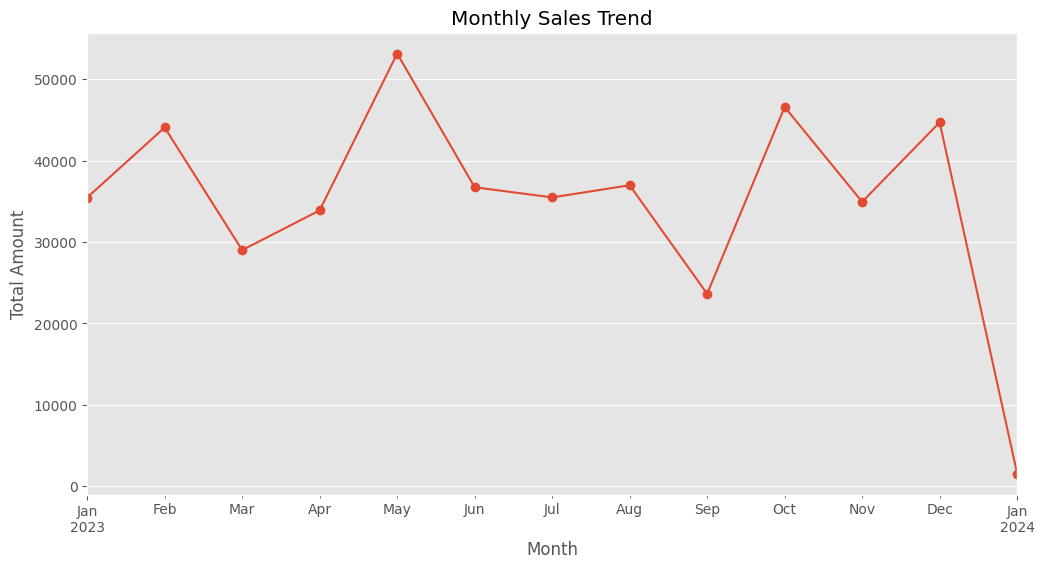

In [36]:
#MONTHLY SALES ANALYSIS
# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Remove rows with invalid dates
df = df.dropna(subset=['Date'])

# Create Month column
df['Month'] = df['Date'].dt.to_period('M')

# Calculate monthly sales
monthly_sales = df.groupby('Month')['Total Amount'].sum()

# Plot
plt.figure(figsize=(12,6))
monthly_sales.plot(marker='o')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Amount")
plt.grid(True)
plt.show()

In [37]:
monthly_sales = df.groupby('Month')['Total Amount'].agg(
    Total_Sales='sum',
    Average_Sales='mean',
    Transactions='count'
)

print(monthly_sales)

         Total_Sales  Average_Sales  Transactions
Month                                            
2023-01        35450     466.447368            76
2023-02        44060     518.352941            85
2023-03        28990     397.123288            73
2023-04        33870     393.837209            86
2023-05        53150     506.190476           105
2023-06        36715     476.818182            77
2023-07        35465     492.569444            72
2023-08        36960     393.191489            94
2023-09        23620     363.384615            65
2023-10        46580     485.208333            96
2023-11        34920     447.692308            78
2023-12        44690     491.098901            91
2024-01         1530     765.000000             2


   Year  Total Amount
0  2023        454470
1  2024          1530


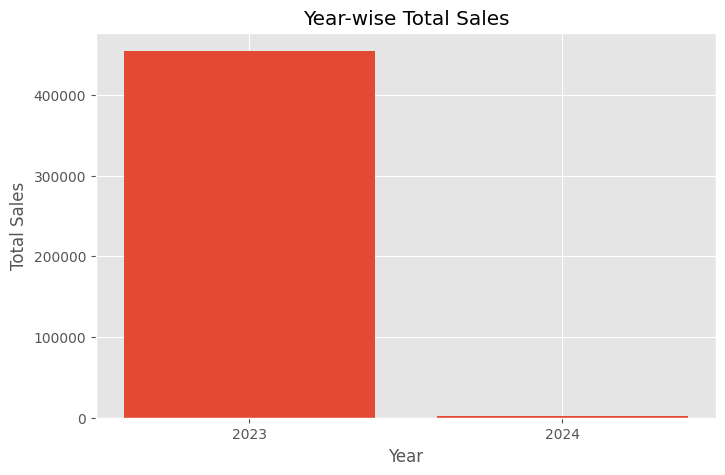

In [38]:
#YEAR WISE SALES ANALYSIS
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Remove invalid dates
df = df.dropna(subset=['Date'])

# Extract Year
df['Year'] = df['Date'].dt.year

# Calculate Year-wise Sales
yearly_sales = df.groupby('Year')['Total Amount'].sum().reset_index()

print(yearly_sales)

plt.figure(figsize=(8,5))

plt.bar(yearly_sales['Year'].astype(str),
        yearly_sales['Total Amount'])

plt.title("Year-wise Total Sales")
plt.xlabel("Year")
plt.ylabel("Total Sales")

plt.show()

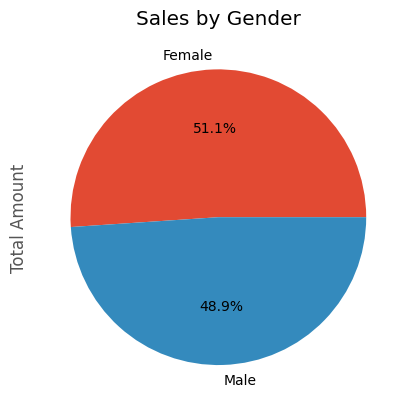

In [ ]:
#CUSTOMER SEGMENT ANALYSIS
# Sales by Gender
gender_sales = df.groupby('Gender')['Total Amount'].sum()

gender_sales.plot(kind='pie', autopct='%1.1f%%')
plt.title("Sales by Gender")
plt.show()

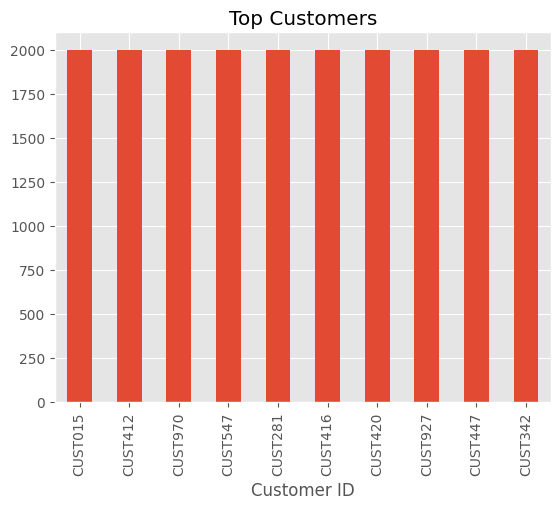

In [ ]:
#TOP CUSTOMERS
top_customers = df.groupby('Customer ID')['Total Amount'].sum().sort_values(ascending=False).head(10)

top_customers.plot(kind='bar')
plt.title("Top Customers")
plt.show()

Product Category
Electronics    156905
Clothing       155580
Beauty         143515
Name: Total Amount, dtype: int64


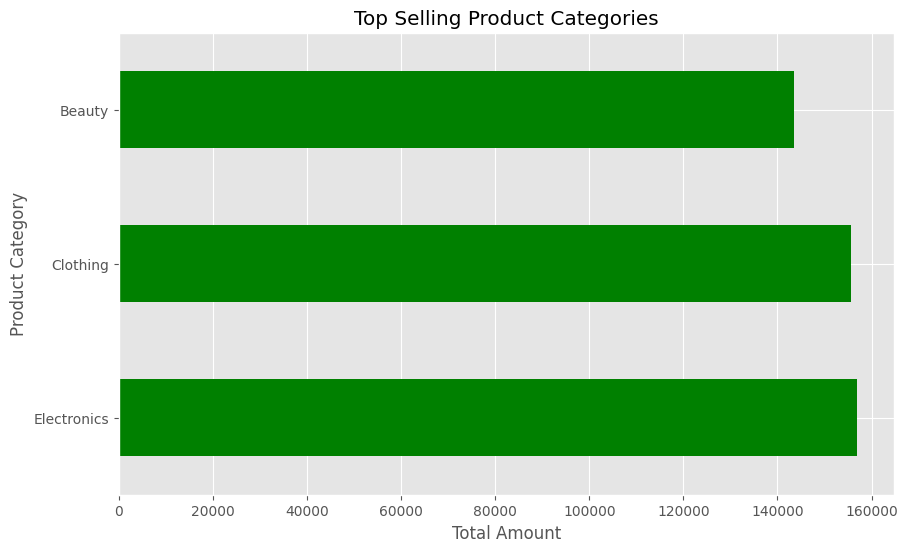

In [ ]:
#PRODUCT CATEGORY ANALYSIS
products = df.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False).head(10)

print(products)

plt.figure(figsize=(10,6))
products.plot(kind='barh', color='green')
plt.title("Top Selling Product Categories")
plt.xlabel("Total Amount")
plt.ylabel("Product Category")
plt.show()

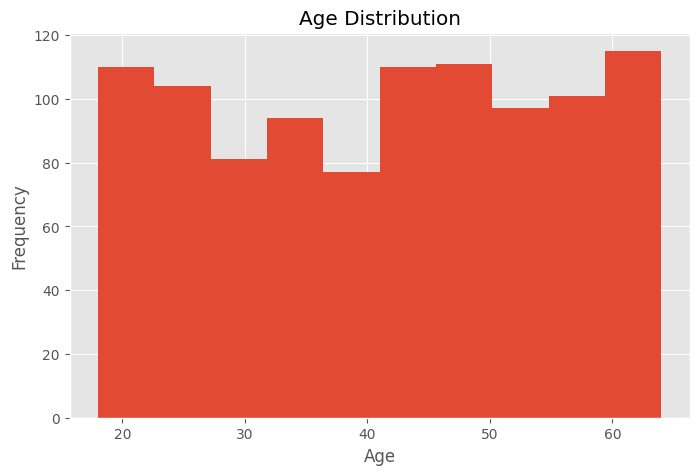

In [44]:
#AGE WISE SALES ANALYSIS
plt.figure(figsize=(8,5))
plt.hist(df['Age'], bins=10)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

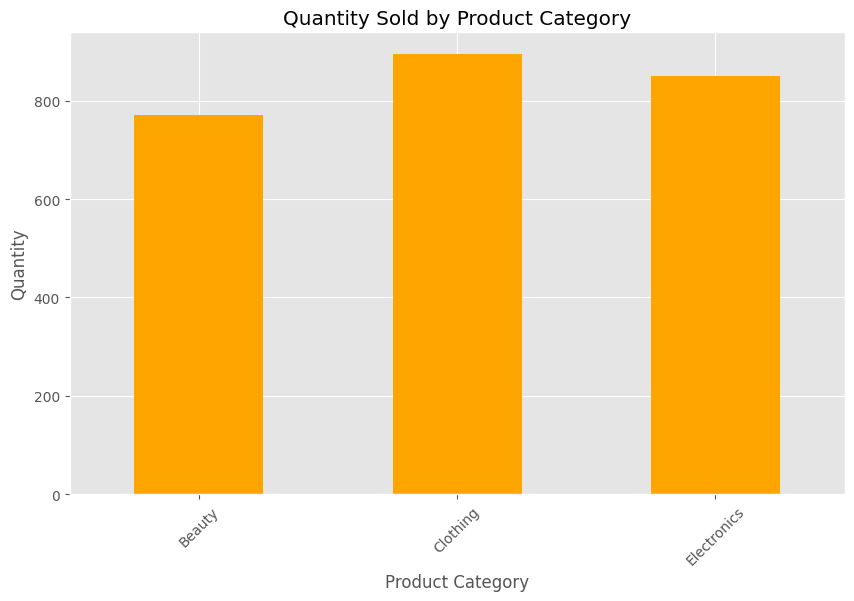

In [43]:
#PRODUCT QUANTITY WISE SALES ANALYSIS
quantity = df.groupby('Product Category')['Quantity'].sum()

plt.figure(figsize=(10,6))
quantity.plot(kind='bar', color='orange')
plt.title("Quantity Sold by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Quantity")
plt.xticks(rotation=45)
plt.show()

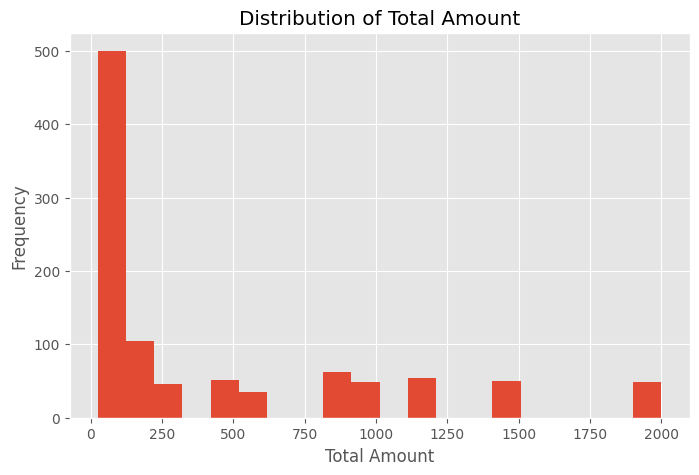

In [42]:
#TOTAL SALES ANALYSIS
plt.figure(figsize=(8,5))
plt.hist(df['Total Amount'], bins=20)
plt.title("Distribution of Total Amount")
plt.xlabel("Total Amount")
plt.ylabel("Frequency")
plt.show()

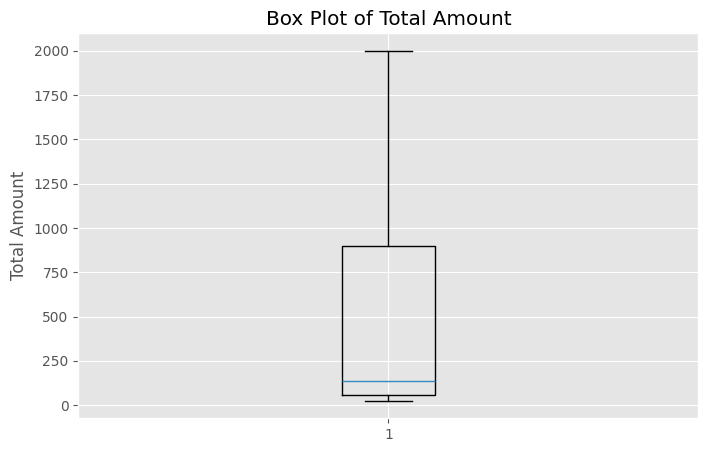

In [41]:
#TOTAL AMOUNT
plt.figure(figsize=(8,5))
plt.boxplot(df['Total Amount'])
plt.title("Box Plot of Total Amount")
plt.ylabel("Total Amount")
plt.show()

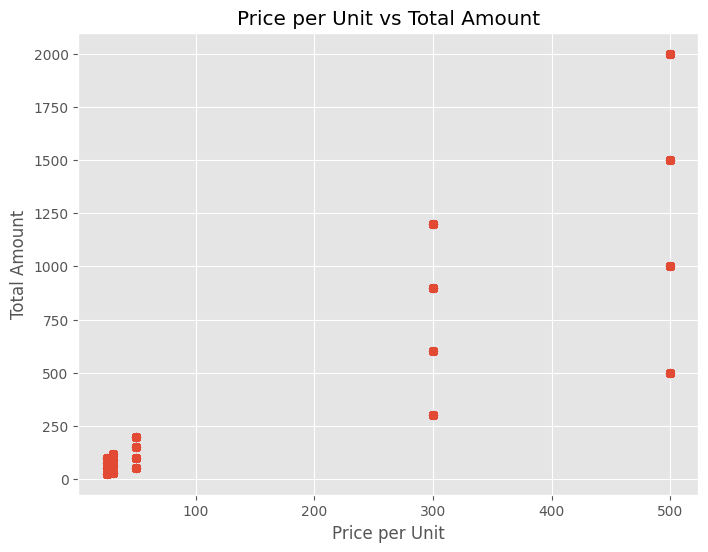

In [40]:
#PRICE PER UNIT ANALYSIS
plt.figure(figsize=(8,6))
plt.scatter(df['Price per Unit'], df['Total Amount'])
plt.title("Price per Unit vs Total Amount")
plt.xlabel("Price per Unit")
plt.ylabel("Total Amount")
plt.show()

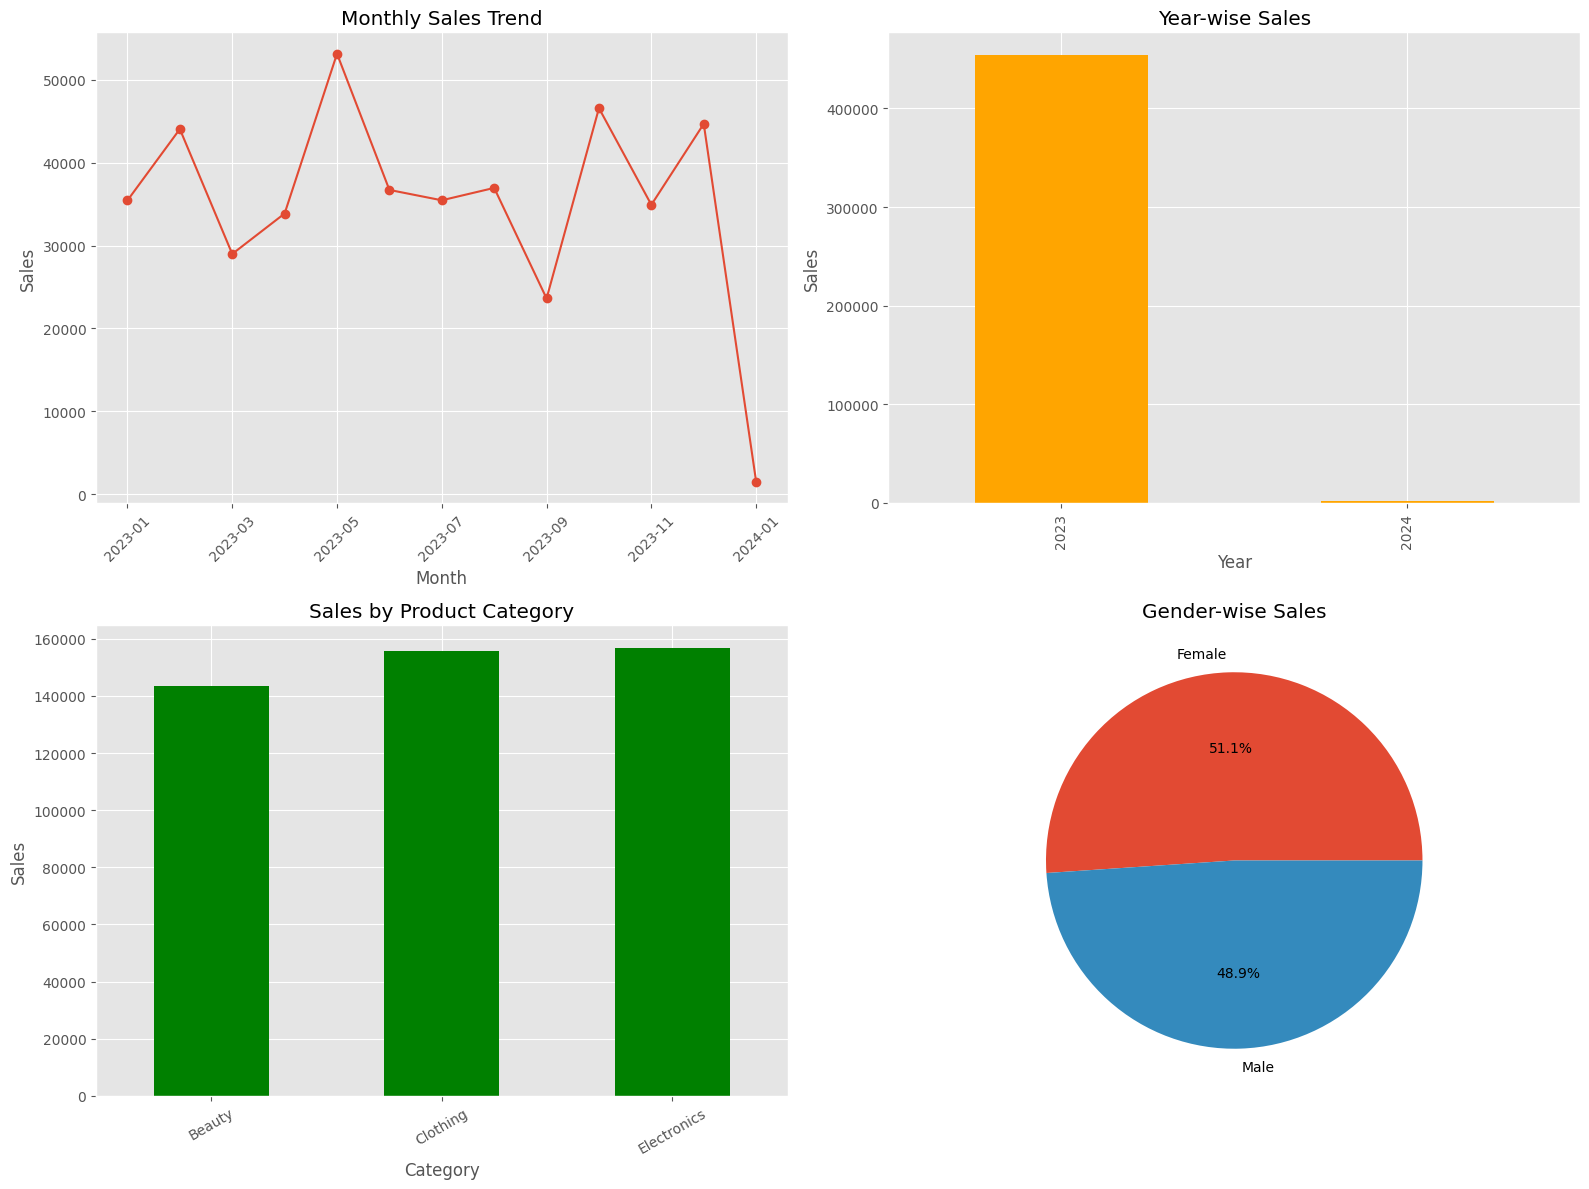

In [39]:
#DASHBOARD

# Convert Date column
df['Date'] = pd.to_datetime(df['Date'])

# Create Month and Year columns
df['Month'] = df['Date'].dt.strftime('%Y-%m')
df['Year'] = df['Date'].dt.year

# Summary data
monthly_sales = df.groupby('Month')['Total Amount'].sum()
yearly_sales = df.groupby('Year')['Total Amount'].sum()
category_sales = df.groupby('Product Category')['Total Amount'].sum()
gender_sales = df.groupby('Gender')['Total Amount'].sum()

# Dashboard
fig, ax = plt.subplots(2, 2, figsize=(16, 12))

# 1 Monthly Sales
monthly_sales.plot(ax=ax[0,0], marker='o')
ax[0,0].set_title("Monthly Sales Trend")
ax[0,0].set_xlabel("Month")
ax[0,0].set_ylabel("Sales")
ax[0,0].tick_params(axis='x', rotation=45)

# 2 Yearly Sales
yearly_sales.plot(kind='bar', ax=ax[0,1], color='orange')
ax[0,1].set_title("Year-wise Sales")
ax[0,1].set_xlabel("Year")
ax[0,1].set_ylabel("Sales")

# 3 Product Category
category_sales.plot(kind='bar', ax=ax[1,0], color='green')
ax[1,0].set_title("Sales by Product Category")
ax[1,0].set_xlabel("Category")
ax[1,0].set_ylabel("Sales")
ax[1,0].tick_params(axis='x', rotation=30)

# 4 Gender Distribution
gender_sales.plot(kind='pie',
                  autopct='%1.1f%%',
                  ax=ax[1,1])
ax[1,1].set_title("Gender-wise Sales")
ax[1,1].set_ylabel("")

plt.tight_layout()
plt.show()